[Accueil](../../index.ipynb) > [Sommaire](../index.ipynb) > [Réseau](index.ipynb)

# TP 2

Le but de ce TP est de créer un réseau très simple en utilisant tout à tour un **hub** puis un **switch** grâce au logiciel [GNS3](https://www.gns3.com/).

Nous allons également observer les échanges de paquets à travers le réseau grace au logiciel [WireShark](https://www.wireshark.org/).

## Création d'un simple réseau avec un hub

- Ouvrir le logiciel GNS3 puis créer le projet TP2.
- Créer le réseau ci-dessous
- Démarrer les PCs virtuels

![tp2_img1.png](https://github.com/saintlouis29/coursNSI/blob/main/Premiere/6_Architecture/6_2_Reseau/img/tp2_img1.png?raw=1)

### Configuration du réseau

Ce réseau ne contiendra jamais plus de 4 hôtes.
On souhaiterait utiliser le réseau 10.0.0.0

**Questions**:

1. Quel masque de sous-réseau peut-on utiliser en minimisant la plage d'adresses IP possible ?
2. Donner les adresses IP du broadcast pour ce réseau:
3. Lister les adresses IP que vous allez utiliser pour chacune des machines;
4. Combien d'adresses IP reste-t-il de libre pour d'éventuels ajouts ?

**Commandes**:

<figure style="float:right">
    <img src="https://github.com/saintlouis29/coursNSI/blob/main/Premiere/6_Architecture/6_2_Reseau/img/tp2_img2.png?raw=1"
         alt="Les commandes disponibles sur les pcs virtuels"
     ![tp2_img2.png](attachment:4c9771eb-31a6-4588-a75f-94ea9213f388.png)    title="Les commandes disponibles sur les pcs virtuels"
         >
    <figcaption>Les commandes disponibles sur les pcs virtuels</figcaption>
</figure>


- Sur chaque VPC :
  - Clic droit > Console
  - *?* (pour lister les commandes possibles).
  - *ip ?* pour la configuraton d'une machine.
  - configurer chaque machine avec la commande adéquate.
  - utiliser la commande *show* pour afficher les caractéristiques réseau de la machine.
  

### Test du réseau

#### Le protocole ARP

**ARP**, comme **A**dress **R**esolution **P**rotocol, permet de faire **le lien entre une adresse IP d'une carte réseau et une adresse matérielle** dite adresse MAC. Plus précisément, son but est, à partir d'une adresse IP connue d'une machine, obtenir son adresse MAC et ainsi pouvoir envoyer notre trame.

Sur chacun des postes lancer la commande *arp*.

**Question** : Quel est l'état des tables ?

les tables sont vides

#### Observation fine

Nous allons utiliser le logiciel wireshark afin d'observer finement les échanges entre machines.

- Sur la liaison filaire PC1/hub > clic droit > Start capture
- Depuis le terminal PC1 lancer la commande *ping 10.0.0.2 -c 1* (-c 1 permet de faire un seul ping au lieu de 4 par défaut)

Prendre une capture d'écran des 4 paquets qui ont transité. Vous avez normalement 2 paquets de protocole ARP et 2 paquets du protocole ICMP

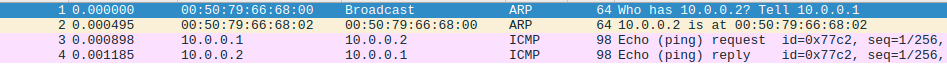

Compléter le tableau suivant:

| paquet n° | protocole | source | destination | rôle du paquet |
|-----------|-----------|--------|-------------|----------------|
| 1         | ARP       |        |             |                |
| 2         | ARP       |        |             |                |
| 3         | ICMP      |        |             |                |
| 3         | ICMP      |        |             |                |

- Se renseigner plus précisement sur le protocole **ARP**, notamment à quelle couche du modèle OSI il appartient.
- Se renseigner plus précisement sur le protocole **ICMP**, notamment à quelle couche du modèle OSI il appartient.

#### Remplissage de la table ARP

- Toujours depuis le PC1, relancer la commande *ping 10.0.0.2 -c 1*
- Depuis le PC1, lancer la commande *arp*. Quel est, cette fois, ci le contenu de la table ?

00:50:79:66:68:02  10.0.0.2 expires in 97 seconds
mais expire au bout de 2 minutes sur GNS3.

- Relancer le *ping 10.0.0.2 -c 1*, cette fois ci combien de paquets transitent  et pour quelle raison ?

4 de plus

- Lancer le *ping 10.0.0.3 -c 1*, puis la commande *arp*. Quel est le contenu de la table ARP ?

00:50:79:66:68:02  10.0.0.2 expires in 89 seconds
00:50:79:66:68:01  10.0.0.3 expires in 107 seconds

## HUB vs Switch

- Sniffer la liaison hub/PC3 avec Wireshark
- Depuis le PC1 pinger PC2

Qu'observez-vous sur la liaison hub/PC3 ?

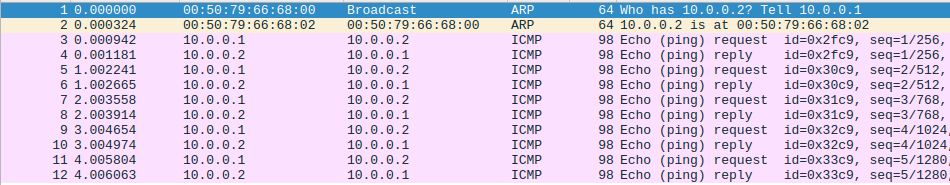

- Remplacer le hub par un **switch ethernet**, votre réseau ressemble maintenant à ceci:

![tp2_img3.png](https://github.com/saintlouis29/coursNSI/blob/main/Premiere/6_Architecture/6_2_Reseau/img/tp2_img3.png?raw=1)

Refaire la manipulation précédente.

- Les paquets transitent-ils toujours sur la liaison Switch/PC3 ?

non il ne transit plus :
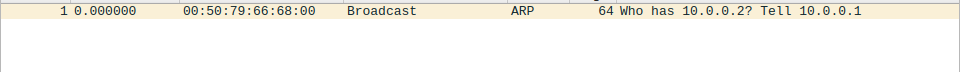

- Se renseigner, sur le web, sur la différence entre un hub et un switch.

Un hub est un équipement réseau qui transmet les données reçues à tous les appareils connectés, sans distinguer le destinataire. Il fonctionne à la couche 1 (physique) du modèle OSI, ce qui provoque beaucoup de trafic inutile et des collisions possibles.

Un switch est plus intelligent : il apprend les adresses MAC des machines connectées et envoie les données uniquement vers le port du destinataire. Il fonctionne à la couche 2 (liaison de données) du modèle OSI, ce qui améliore les performances et réduit le trafic sur le réseau.